In [14]:
import math

class Value: 
    
    def __init__(self, data, _children = (), _op ='', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =Value((self.data + other.data), (self,other), '+')
        
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance (other, Value) else Value(other)
        out =Value((self.data * other.data), (self,other), '*')
        
        def _backward():
            self.grad+= other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self*-1
    
    def __sub__(self, other):
        return self+ (-other)
    
    def __rmul__(self, other):
        
        return self*other
    
    def __pow__(self,other):
        assert isinstance (other,(float, int)), "only supporting int and float type !"
        out = Value(self.data**other, (self,), f'**{other}')
        
        def _backward():
            self.grad += other*(self.data**(other-1))* out.grad
        out._backward= _backward
        
        return out 
        
    def __truediv__(self, other):
        return self*(other**-1)
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
         
        def _backward():                          
            self.grad += out.data * out.grad      
        out._backward = _backward    
        
        return out
    
    def tanh(self):
        n = self.data 
        t = ((math.exp(2*n) -1)/(math.exp(2*n) + 1))
        out = Value(t, (self,), 'tanh')
        
        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo = []
        visited = set()
    
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
    
        build_topo(self)
    
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        
    

In [2]:
a = Value(2, label = 'a')
b= Value(-3, label = 'b')
c = Value(10, label = 'c')
e = a*b; e.label = 'e'
d = e+c; d.label= 'd'
f = Value(-2, label = 'f')
L = d*f; L.label = 'L'

In [3]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f| grad %.4f }" % (n.label, n.data,n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

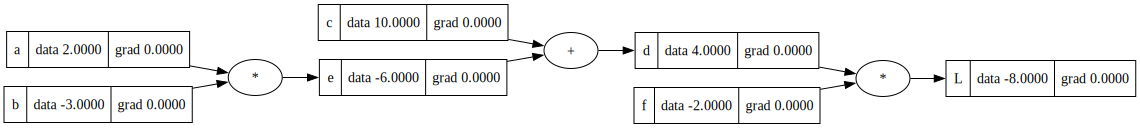

In [4]:
draw_dot(L)

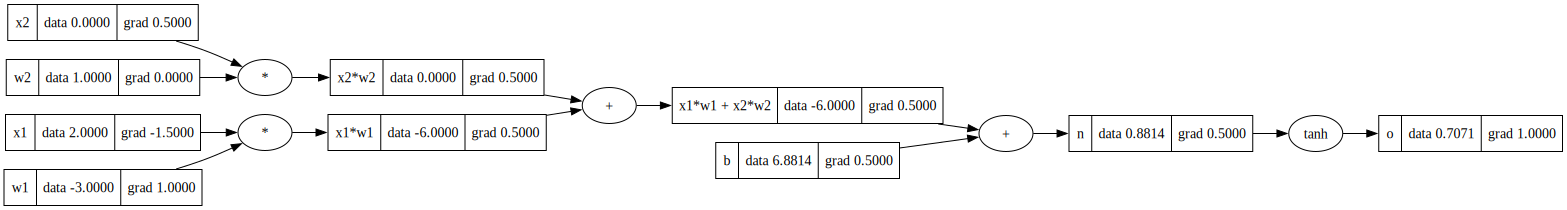

In [5]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label ='o'
o.backward()
draw_dot(o)

In [6]:
# do/dn , o = tanh(n), do/dn = 1-tanh(n)**2

In [7]:
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.88137),
 Value(data=0.8813700000000004),
 Value(data=0.7071049876722272)]

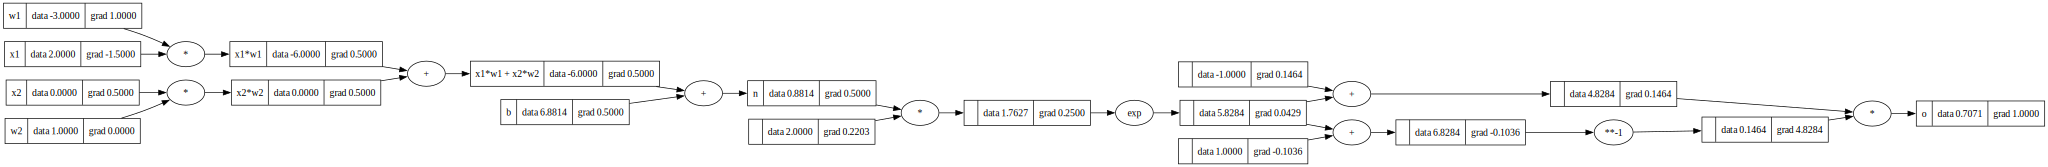

In [8]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e-1)/(e+1); o.label = 'o'
o.backward()
draw_dot(o)

In [9]:
import torch

In [10]:
import torch

x1 = torch.Tensor([2.0]).double()         ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()         ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()        ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()         ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [247]:
import random

class Neuron: 
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]  # [w0, w1, ..., b]

    
class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    
class MLP:
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0] if len(x) == 1 else x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


x = [2.0, 3.0, -1]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.6194330151294748)

In [248]:
xs = [
    [2.0,  3.0, -1.0],
    [3.0, -1.0,  0.5],
    [0.5,  1.0,  1.0],
    [1.0,  1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  

ypred = [n(x) for x in xs]
ypred

[Value(data=-0.6194330151294748),
 Value(data=-0.3409344943470847),
 Value(data=-0.7112206964635188),
 Value(data=-0.6566307546918634)]

In [268]:
for k in range(5000):
    # forward
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))
    
    # grad sıfırla
    for p in n.parameters():
        p.grad = 0.0
    
    # backward
    loss.backward()
    
    # güncelle
    for p in n.parameters():
        p.data += -0.7894 * p.grad
    
    print(k, loss.data)

0 1.9921954592497975e-06
1 1.9920025295768535e-06
2 1.991809636827006e-06
3 1.9916167809881978e-06
4 1.9914239620509486e-06
5 1.9912311800040256e-06
6 1.991038434837771e-06
7 1.990845726540404e-06
8 1.990653055102309e-06
9 1.9904604205130926e-06
10 1.990267822761627e-06
11 1.9900752618375802e-06
12 1.9898827377303827e-06
13 1.9896902504302027e-06
14 1.9894977999255274e-06
15 1.9893053862066333e-06
16 1.9891130092626613e-06
17 1.988920669082858e-06
18 1.988728365657166e-06
19 1.9885360989750713e-06
20 1.9883438690262825e-06
21 1.98815167579988e-06
22 1.987959519285307e-06
23 1.9877673994724583e-06
24 1.987575316350936e-06
25 1.9873832699099162e-06
26 1.9871912601390636e-06
27 1.9869992870283183e-06
28 1.9868073505665265e-06
29 1.986615450743917e-06
30 1.986423587549744e-06
31 1.9862317609732397e-06
32 1.9860399710045756e-06
33 1.98584821763341e-06
34 1.9856565008481464e-06
35 1.985464820639888e-06
36 1.9852731769973495e-06
37 1.985081569910182e-06
38 1.9848899993681346e-06
39 1.98469846

371 1.9230666718637434e-06
372 1.9228867488083617e-06
373 1.9227068590218478e-06
374 1.9225270024952027e-06
375 1.9223471792184637e-06
376 1.9221673891832977e-06
377 1.921987632380171e-06
378 1.9218079087996235e-06
379 1.92162821843314e-06
380 1.9214485612711253e-06
381 1.9212689373045647e-06
382 1.9210893465238926e-06
383 1.9209097889205385e-06
384 1.920730264485403e-06
385 1.920550773208819e-06
386 1.9203713150819814e-06
387 1.9201918900955647e-06
388 1.9200124982401318e-06
389 1.919833139507566e-06
390 1.9196538138877736e-06
391 1.919474521372066e-06
392 1.9192952619512333e-06
393 1.9191160356160575e-06
394 1.9189368423579553e-06
395 1.9187576821665307e-06
396 1.918578555034143e-06
397 1.9183994609509866e-06
398 1.9182203999078136e-06
399 1.9180413718958495e-06
400 1.9178623769060353e-06
401 1.917683414928875e-06
402 1.917504485955498e-06
403 1.9173255899769037e-06
404 1.91714672698415e-06
405 1.9169678969678707e-06
406 1.9167890999188867e-06
407 1.9166103358286446e-06
408 1.9164316

731 1.8603756322505105e-06
732 1.8602071175079638e-06
733 1.8600386329348918e-06
734 1.8598701785233764e-06
735 1.8597017542645046e-06
736 1.8595333601510351e-06
737 1.8593649961746989e-06
738 1.8591966623273413e-06
739 1.8590283586010517e-06
740 1.8588600849874631e-06
741 1.8586918414789425e-06
742 1.858523628067165e-06
743 1.8583554447441434e-06
744 1.8581872915023755e-06
745 1.85801916833265e-06
746 1.857851075228234e-06
747 1.8576830121800312e-06
748 1.8575149791808778e-06
749 1.8573469762220037e-06
750 1.857179003296412e-06
751 1.8570110603947776e-06
752 1.856843147509934e-06
753 1.8566752646334945e-06
754 1.8565074117577009e-06
755 1.856339588875057e-06
756 1.856171795976502e-06
757 1.8560040330546633e-06
758 1.8558363001011667e-06
759 1.855668597108422e-06
760 1.8555009240683511e-06
761 1.85533328097309e-06
762 1.8551656678141978e-06
763 1.8549980845838675e-06
764 1.8548305312744017e-06
765 1.8546630078774888e-06
766 1.854495514385715e-06
767 1.8543280507904766e-06
768 1.8541606

1091 1.8015995999699063e-06
1092 1.801441446391898e-06
1093 1.8012833202562737e-06
1094 1.8011252215559707e-06
1095 1.8009671502837125e-06
1096 1.800809106432117e-06
1097 1.800651089994942e-06
1098 1.8004931009648047e-06
1099 1.8003351393340093e-06
1100 1.8001772050962136e-06
1101 1.8000192982436825e-06
1102 1.7998614187699145e-06
1103 1.7997035666672272e-06
1104 1.7995457419292348e-06
1105 1.7993879445486302e-06
1106 1.7992301745176913e-06
1107 1.7990724318303713e-06
1108 1.7989147164786334e-06
1109 1.7987570284559866e-06
1110 1.7985993677552078e-06
1111 1.798441734369339e-06
1112 1.7982841282911128e-06
1113 1.7981265495135991e-06
1114 1.7979689980296103e-06
1115 1.7978114738321486e-06
1116 1.7976539769144537e-06
1117 1.7974965072690226e-06
1118 1.7973390648887345e-06
1119 1.7971816497672428e-06
1120 1.7970242618970457e-06
1121 1.796866901271022e-06
1122 1.7967095678821877e-06
1123 1.7965522617231434e-06
1124 1.7963949827878729e-06
1125 1.7962377310684136e-06
1126 1.7960805065579758e-

1443 1.747575082739304e-06
1444 1.7474261667447455e-06
1445 1.747277275834272e-06
1446 1.7471284100017518e-06
1447 1.746979569240503e-06
1448 1.7468307535442873e-06
1449 1.7466819629073232e-06
1450 1.7465331973231233e-06
1451 1.7463844567848028e-06
1452 1.7462357412868586e-06
1453 1.7460870508225913e-06
1454 1.7459383853853668e-06
1455 1.7457897449700608e-06
1456 1.7456411295690106e-06
1457 1.7454925391769992e-06
1458 1.7453439737869302e-06
1459 1.7451954333930693e-06
1460 1.7450469179889115e-06
1461 1.7448984275678504e-06
1462 1.744749962124456e-06
1463 1.7446015216519658e-06
1464 1.7444531061441158e-06
1465 1.7443047155944234e-06
1466 1.7441563499971498e-06
1467 1.7440080093453564e-06
1468 1.7438596936333233e-06
1469 1.7437114028549385e-06
1470 1.7435631370030583e-06
1471 1.7434148960722737e-06
1472 1.7432666800559035e-06
1473 1.7431184889480395e-06
1474 1.7429703227426944e-06
1475 1.7428221814322392e-06
1476 1.7426740650117658e-06
1477 1.7425259734749233e-06
1478 1.7423779068146963e

...

3211 1.518419484206558e-06
3212 1.5183067000418069e-06
3213 1.5181939324419434e-06
3214 1.51808118140384e-06
3215 1.5179684469243037e-06
3216 1.5178557289983175e-06
3217 1.5177430276234618e-06
3218 1.5176303427950694e-06
3219 1.5175176745110142e-06
3220 1.5174050227659845e-06
3221 1.5172923875573632e-06
3222 1.5171797688815588e-06
3223 1.5170671667346937e-06
3224 1.5169545811127586e-06
3225 1.5168420120123976e-06
3226 1.51672945943077e-06
3227 1.516616923363032e-06
3228 1.5165044038065844e-06
3229 1.5163919007572846e-06
3230 1.5162794142111736e-06
3231 1.5161669441653145e-06
3232 1.5160544906162106e-06
3233 1.5159420535592922e-06
3234 1.5158296329917954e-06
3235 1.5157172289097451e-06
3236 1.515604841309757e-06
3237 1.5154924701879254e-06
3238 1.5153801155408897e-06
3239 1.5152677773649444e-06
3240 1.5151554556566814e-06
3241 1.515043150412126e-06
3242 1.514930861627964e-06
3243 1.5148185893003573e-06
3244 1.5147063334259679e-06
3245 1.5145940940009023e-06
3246 1.5144818710221567e-06
3

3571 1.4788603271131131e-06
3572 1.4787532795942082e-06
3573 1.4786462473986542e-06
3574 1.4785392305227834e-06
3575 1.4784322289633851e-06
3576 1.4783252427169894e-06
3577 1.4782182717806853e-06
3578 1.478111316151258e-06
3579 1.478004375825209e-06
3580 1.477897450798967e-06
3581 1.4777905410697629e-06
3582 1.477683646634562e-06
3583 1.4775767674891837e-06
3584 1.477469903630824e-06
3585 1.47736305505701e-06
3586 1.4772562217630032e-06
3587 1.4771494037465354e-06
3588 1.4770426010038365e-06
3589 1.47693581353256e-06
3590 1.4768290413284266e-06
3591 1.4767222843882063e-06
3592 1.4766155427094043e-06
3593 1.4765088162880632e-06
3594 1.4764021051214002e-06
3595 1.4762954092056892e-06
3596 1.476188728537891e-06
3597 1.4760820631152913e-06
3598 1.4759754129335215e-06
3599 1.4758687779906277e-06
3600 1.4757621582819407e-06
3601 1.4756555538056064e-06
3602 1.4755489645576397e-06
3603 1.4754423905344682e-06
3604 1.4753358317333481e-06
3605 1.4752292881511749e-06
3606 1.4751227597842055e-06
36

3931 1.4412887663250501e-06
3932 1.4411870304333467e-06
3933 1.441085308743689e-06
3934 1.4409836012524187e-06
3935 1.4408819079571878e-06
3936 1.4407802288551112e-06
3937 1.4406785639423393e-06
3938 1.4405769132168337e-06
3939 1.4404752766754293e-06
3940 1.440373654314758e-06
3941 1.4402720461326945e-06
3942 1.440170452125679e-06
3943 1.4400688722904935e-06
3944 1.4399673066247899e-06
3945 1.4398657551254243e-06
3946 1.4397642177894536e-06
3947 1.4396626946138894e-06
3948 1.4395611855956449e-06
3949 1.4394596907316718e-06
3950 1.4393582100195435e-06
3951 1.4392567434558043e-06
3952 1.4391552910383776e-06
3953 1.4390538527628485e-06
3954 1.4389524286277513e-06
3955 1.4388510186288776e-06
3956 1.4387496227642373e-06
3957 1.4386482410306982e-06
3958 1.4385468734246447e-06
3959 1.4384455199439023e-06
3960 1.4383441805853224e-06
3961 1.4382428553464045e-06
3962 1.438141544222893e-06
3963 1.4380402472131927e-06
3964 1.4379389643138112e-06
3965 1.4378376955216813e-06
3966 1.4377364408341338e

4291 1.4055592878926632e-06
4292 1.4054624794902045e-06
4293 1.4053656842741631e-06
4294 1.405268902242691e-06
4295 1.4051721333932483e-06
4296 1.4050753777221846e-06
4297 1.4049786352277938e-06
4298 1.4048819059070937e-06
4299 1.404785189757059e-06
4300 1.4046884867752997e-06
4301 1.404591796959262e-06
4302 1.4044951203062163e-06
4303 1.4043984568132577e-06
4304 1.4043018064781736e-06
4305 1.4042051692976063e-06
4306 1.4041085452695312e-06
4307 1.4040119343907466e-06
4308 1.403915336658893e-06
4309 1.4038187520713084e-06
4310 1.4037221806255002e-06
4311 1.4036256223180028e-06
4312 1.4035290771470412e-06
4313 1.4034325451096503e-06
4314 1.4033360262030916e-06
4315 1.4032395204245718e-06
4316 1.4031430277717381e-06
4317 1.4030465482417875e-06
4318 1.4029500818317402e-06
4319 1.402853628539473e-06
4320 1.4027571883620385e-06
4321 1.4026607612966635e-06
4322 1.4025643473408722e-06
4323 1.402467946491961e-06
4324 1.4023715587472966e-06
4325 1.4022751841044043e-06
4326 1.4021788225599387e-0

4651 1.3715402131114424e-06
4652 1.3714479841468032e-06
4653 1.371355767449139e-06
4654 1.3712635630152171e-06
4655 1.3711713708430038e-06
4656 1.371079190930154e-06
4657 1.3709870232741758e-06
4658 1.3708948678718527e-06
4659 1.3708027247218347e-06
4660 1.3707105938214835e-06
4661 1.3706184751682147e-06
4662 1.3705263687590874e-06
4663 1.370434274592218e-06
4664 1.3703421926652897e-06
4665 1.3702501229756172e-06
4666 1.3701580655208756e-06
4667 1.3700660202988572e-06
4668 1.3699739873062975e-06
4669 1.3698819665414919e-06
4670 1.3697899580019327e-06
4671 1.3696979616852055e-06
4672 1.3696059775888003e-06
4673 1.3695140057099716e-06
4674 1.3694220460470875e-06
4675 1.3693300985973165e-06
4676 1.3692381633576927e-06
4677 1.369146240326581e-06
4678 1.3690543295011663e-06
4679 1.3689624308792704e-06
4680 1.3688705444581828e-06
4681 1.3687786702355076e-06
4682 1.3686868082092173e-06
4683 1.368594958376542e-06
4684 1.3685031207350067e-06
4685 1.368411295282437e-06
4686 1.3683194820165305e-0

In [269]:
ypred

[Value(data=0.999533063309259),
 Value(data=-0.9993553004244153),
 Value(data=-0.9995138957660574),
 Value(data=0.9993142858961634)]